In [1]:
# load packages
import os
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from Library.data_preprocessor import DataPreprocessor

Poznamky velke mnozstvi duplicit asi naklonovani jedne a te same datove sady pod sebe.

f_7,f_8,f_9,f_10,f_11 jedna se o metriky filmu

f_7 - Duration in minutes
f_8 - program_id_score
f_9 - is_series
f_10 - zanr filmu
f_11 - produkce filmu

In [23]:
# load data
data_path = os.path.join(project_root, 'raw_data.csv')
df = pd.read_csv(data_path, low_memory=False)
df['timeslot_datetime_from'] = pd.to_datetime(df['timeslot_datetime_from'])

# --- IMPLEMENTATION ---
FIX_COLS = ['main_ident', 'timeslot_datetime_from', 'channel_id', 'share_15_54', 'share_15_54_3mo_mean']
TARGET = 'share_15_54'

preprocessor = DataPreprocessor(FIX_COLS, TARGET)
processed_df = preprocessor.run(df)



EDA CHANNEL

In [30]:
df.loc[(df.channel_id == 9) & (df.timeslot_datetime_from >= '2023-10-01 16:25:00')]

,main_ident,timeslot_datetime_from,channel_id,share_15_54,share_15_54_3mo_mean,ch9__f_1,ch9__f_3,ch9__f_2,ch9__f_4,ch9__f_6,...,ch4__f_2,ch4__f_4,ch4__f_6,ch4__f_5,ch4__f_7,ch4__f_8,ch4__f_9,ch4__f_10,ch4__f_11,ch4__f_12
31611,92311102206510020,2023-11-10 23:20:00,9,4.556970,6.883297,0.702703,66.017550,57.0,61.272640,38.333332,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
31612,92311102206510020,2023-11-10 23:20:00,9,4.556970,6.883297,0.702703,66.017550,57.0,61.272640,38.333332,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
31613,92311102206510020,2023-11-10 23:20:00,9,4.556970,6.883297,0.702703,66.017550,57.0,61.272640,38.333332,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
31614,92311102206510020,2023-11-10 23:20:00,9,4.556970,6.883297,0.702703,66.017550,57.0,61.272640,38.333332,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
31626,92311111624160020,2023-11-11 16:50:00,9,5.931980,5.266708,0.319149,68.716050,81.0,62.217434,62.750000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34148,92401131758170020,2024-01-13 19:10:00,9,2.834633,7.698482,0.593750,70.012985,77.0,59.763058,60.750000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34150,92401132006050020,2024-01-13 20:05:00,9,3.333413,7.698482,0.017045,58.767440,43.0,55.897873,52.571430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34151,92401132006050020,2024-01-13 20:05:00,9,3.333413,7.698482,0.017045,58.767440,43.0,55.897873,52.571430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34158,92401132301510020,2024-01-13 23:45:00,9,1.440849,7.698482,0.335664,64.491230,57.0,61.670975,48.800000,...,91.0,59.522728,61.5,12.0,NaN,NaN,NaN,NaN,NaN,1.0


In [20]:
processed_df.loc[(processed_df.channel_id == 9) & (processed_df.month == 10)] 

,main_ident,timeslot_datetime_from,share_15_54,share_15_54_3mo_mean,channel_id,day_of_week,month,hour,is_weekend,is_holiday,...,f_4,f_6,f_1,f_5,f_7,f_8,f_9,f_10,f_11,f_12
6036,92210011622470020,2022-10-01 16:25:00,6.095076,5.320067,9,5,10,16,1,0,...,50.072500,57.428570,0.063636,7.0,NaN,NaN,NaN,None,None,3.0
6037,92210011812170020,2022-10-01 18:55:00,2.058627,4.462689,9,5,10,18,1,0,...,58.426620,30.750000,0.412281,4.0,NaN,NaN,NaN,None,None,4.0
6038,92210012006130020,2022-10-01 20:35:00,6.229203,5.187032,9,5,10,20,1,0,...,65.259950,55.666668,0.277311,9.0,NaN,NaN,NaN,None,None,NaN
6039,92210021621540020,2022-10-02 17:15:00,3.289501,6.061282,9,6,10,17,1,0,...,65.259950,55.666668,0.508772,9.0,NaN,NaN,NaN,None,None,2.0
6040,92210022006440020,2022-10-02 21:00:00,3.469765,5.497357,9,6,10,21,1,0,...,64.112980,69.883720,0.442748,43.0,NaN,NaN,NaN,None,None,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6129,92210301750310020,2022-10-30 18:10:00,8.193465,5.189698,9,6,10,18,1,0,...,57.263160,55.500000,0.177778,12.0,NaN,NaN,NaN,None,None,3.0
6130,92210302006040020,2022-10-30 20:30:00,4.082626,5.045026,9,6,10,20,1,0,...,64.391174,50.571430,0.217054,7.0,NaN,NaN,NaN,None,None,NaN
6131,92210302215100020,2022-10-30 22:15:00,3.841589,6.760156,9,6,10,22,1,0,...,43.657223,60.526318,0.033333,19.0,NaN,NaN,NaN,None,None,2.0
6132,92210311548200020,2022-10-31 16:40:00,7.442199,5.518688,9,0,10,16,0,0,...,58.589970,44.166668,0.538462,6.0,NaN,NaN,NaN,None,None,3.0


In [21]:
processed_df.loc[(processed_df.channel_id == 4) & (processed_df.month == 9)] 

,main_ident,timeslot_datetime_from,share_15_54,share_15_54_3mo_mean,channel_id,day_of_week,month,hour,is_weekend,is_holiday,...,f_4,f_6,f_1,f_5,f_7,f_8,f_9,f_10,f_11,f_12
3532,42209011751400000,2022-09-01 17:50:00,11.744266,10.472055,4,3,9,17,0,0,...,42.044605,25.292156,0.050847,16.000000,44.0,14591.0,0.0,Reality-TV,Česko,NaN
3533,42209012018190000,2022-09-01 20:50:00,23.695917,14.156321,4,3,9,20,0,0,...,44.809948,38.362010,0.450000,23.400000,32.0,1088.0,1.0,Rodinný,Česko,NaN
3534,42209021652550000,2022-09-02 17:10:00,14.001633,9.833348,4,4,9,17,0,0,...,18.232042,30.233334,0.372881,5.666666,15.0,3074.0,0.0,Dokumentární,Česko,NaN
3535,42209022019490000,2022-09-02 20:55:00,22.221160,14.158824,4,4,9,20,0,0,...,18.304607,NaN,0.493827,NaN,11.0,423.0,0.0,Zábavný,Česko,NaN
3536,42209022140160000,2022-09-02 21:45:00,12.648503,12.626577,4,4,9,21,0,0,...,52.171240,56.256250,0.125000,36.000000,50.0,1813.0,1.0,Krimi,Česko,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4867,42309271652580000,2023-09-27 17:15:00,11.249906,11.521988,4,2,9,17,0,0,...,18.232042,30.233334,0.473684,5.666666,NaN,NaN,NaN,None,None,NaN
4868,42309271750350000,2023-09-27 18:25:00,15.552737,11.576304,4,2,9,18,0,0,...,42.044605,25.292156,0.650000,16.000000,NaN,NaN,NaN,None,None,NaN
4869,42309281750240000,2023-09-28 17:50:00,3.058985,11.031740,4,3,9,17,0,1,...,42.044605,25.292156,0.066667,16.000000,NaN,NaN,NaN,None,None,NaN
4870,42309281943130010,2023-09-28 19:40:00,7.240289,9.859315,4,3,9,19,0,1,...,6.911111,NaN,0.100000,NaN,NaN,NaN,NaN,None,None,NaN


In [19]:
processed_df.loc[(processed_df.channel_id == 4) & (processed_df.month == 10)] 

,main_ident,timeslot_datetime_from,share_15_54,share_15_54_3mo_mean,channel_id,day_of_week,month,hour,is_weekend,is_holiday,...,f_4,f_6,f_1,f_5,f_7,f_8,f_9,f_10,f_11,f_12
3640,42210011455420000,2022-10-01 16:25:00,10.499738,11.500196,4,5,10,16,1,0,...,60.276424,62.581394,0.723077,43.000000,56.0,6603.0,0.0,Komedie,Československo,3.0
3641,42210011705160000,2022-10-01 17:20:00,7.977698,10.170960,4,5,10,17,1,0,...,58.703106,59.219513,0.186275,41.000000,80.0,10376.0,0.0,Komedie,Československo,2.0
3642,42210012019520000,2022-10-01 20:35:00,13.964078,15.023304,4,5,10,20,1,0,...,40.231520,26.391304,0.198020,23.000000,50.0,9519.0,0.0,Reality-TV,Česko,NaN
3643,42210021658120000,2022-10-02 17:15:00,13.172759,10.050883,4,6,10,17,1,0,...,56.260693,52.400000,0.192661,45.000000,60.0,9782.0,0.0,Rodinný,Česko,4.0
3644,42210022020240000,2022-10-02 21:00:00,13.050839,15.400984,4,6,10,21,1,0,...,52.483936,54.090908,0.372881,11.000000,62.0,13529.0,0.0,Komedie,Česko,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3743,42210302019170000,2022-10-30 20:30:00,27.021873,15.468584,4,6,10,20,1,0,...,54.299316,44.666668,0.118110,3.000000,70.0,20604.0,0.0,Komedie,Česko,4.0
3744,42210302226080000,2022-10-30 22:50:00,14.951173,9.406205,4,6,10,22,1,0,...,51.601517,58.500000,0.264151,26.000000,NaN,NaN,NaN,None,None,3.0
3745,42210311553510000,2022-10-31 16:40:00,12.376802,10.666256,4,0,10,16,0,0,...,18.232042,30.233334,0.879310,5.666666,15.0,3074.0,0.0,Dokumentární,Česko,1.0
3746,42210311651100000,2022-10-31 17:00:00,15.358282,10.398563,4,0,10,17,0,0,...,18.232042,30.233334,0.220339,5.666666,15.0,3074.0,0.0,Dokumentární,Česko,NaN


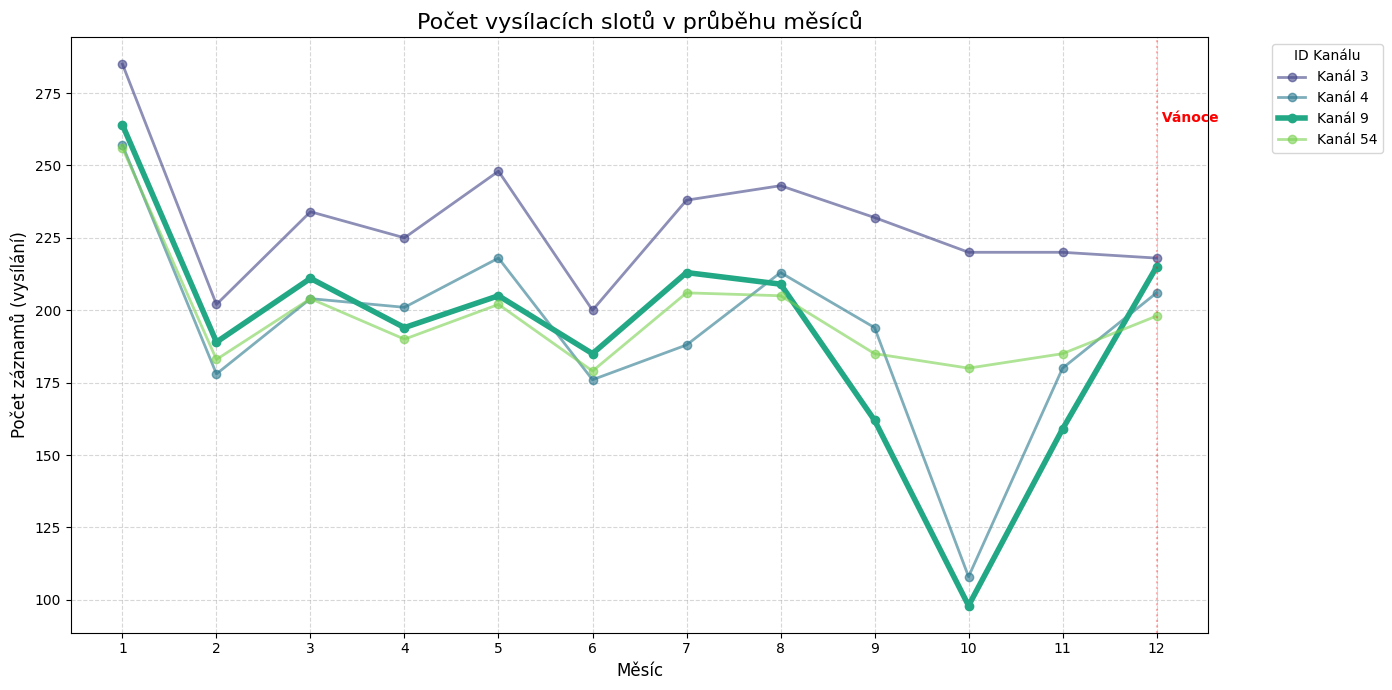

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Příprava dat - seskupení podle měsíce a kanálu
# Předpokládáme, že 'month' už máš v df z preprocessoru
monthly_counts = processed_df.groupby(['month', 'channel_id']).size().unstack()

# 2. Vykreslení
plt.figure(figsize=(14, 7))

# Použijeme automatickou paletu pro odlišení kanálů
colors = sns.color_palette("viridis", n_colors=len(monthly_counts.columns))

for i, col in enumerate(monthly_counts.columns):
    # Zvýrazníme Kanál 9 (Nova News) silnější čarou, pokud ho chceme sledovat
    linewidth = 4 if col == 9 else 2
    alpha = 1.0 if col == 9 else 0.6
    
    plt.plot(monthly_counts.index, monthly_counts[col], 
             marker='o', label=f'Kanál {col}', 
             linewidth=linewidth, alpha=alpha, color=colors[i])

# 3. Formátování grafu
plt.title('Počet vysílacích slotů v průběhu měsíců', fontsize=16)
plt.xlabel('Měsíc', fontsize=12)
plt.ylabel('Počet záznamů (vysílání)', fontsize=12)
plt.xticks(range(1, 13))  # Zajistí popisky pro všech 12 měsíců
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='ID Kanálu', bbox_to_anchor=(1.05, 1), loc='upper left')

# Přidání poznámky k prosinci
plt.axvline(x=12, color='red', linestyle=':', alpha=0.3)
plt.text(12, plt.ylim()[1]*0.9, ' Vánoce', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
processed_df[['channel_id','hour','genre_group']].groupby(['channel_id','hour']).describe()

genre_group                               
                      count unique                top freq
channel_id hour                                           
3          16           367      6   Zábava & Reality  191
           17           290      5   Zábava & Reality  197
           18           365      6  Drama & Romantika  142
           19           379      6   Info & Dokumenty  208
           20           376      7   Zábava & Reality  118
           21           302      7  Drama & Romantika  106
           22           335      6  Drama & Romantika  103
           23           351      6      Akce & Sci-Fi  129
4          16           382      7   Info & Dokumenty  203
           17           390      6   Info & Dokumenty  182
           18           312      6   Zábava & Reality  227
           19           113      2   Info & Dokumenty  107
           20           326      6   Zábava & Reality  123
           21           267      7   Zábava & Reality  123
           22           304      6   Zábava & Reality  181
           23           229      5   Zábava & Reality  121
9          16           423      1    Nefilmovy_obsah  423
           17           238      1    Nefilmovy_obsah  238
           18           352      1    Nefilmovy_obsah  352
           19           168      1    Nefilmovy_obsah  168
           20           384      1    Nefilmovy_obsah  384
           21           197      1    Nefilmovy_obsah  197
           22           320      1    Nefilmovy_obsah  320
           23           222      1    Nefilmovy_obsah  222
54         16           427      6  Drama & Romantika  155
           17           282      6  Drama & Romantika   87
           18           353      6      Akce & Sci-Fi   94
           19           119      6   Zábava & Reality   44
           20           429      6   Zábava & Reality  128
           21           201      7      Akce & Sci-Fi   54
           22           317      6      Akce & Sci-Fi  117
           23           245      4      Akce & Sci-Fi  106

In [10]:
processed_df[['genre_group','f_5']].groupby('genre_group').describe()

f_5                                                   \
                    count       mean        std  min        25%        50%   
genre_group                                                                  
Akce & Sci-Fi      1078.0  18.919609  12.470125  2.0   9.000000  16.000000   
Drama & Romantika  1709.0  21.771557  14.103392  2.0  12.000000  21.000000   
Děti & Rodina       254.0  23.888058  16.324781  2.0  14.250000  23.400000   
Info & Dokumenty    673.0   6.706538   2.145775  2.0   5.666666   5.666666   
Nefilmovy_obsah    3441.0  19.607212  19.162413  2.0   8.000000  15.000000   
Ostatní              52.0  18.875000  19.950398  2.0   5.750000  14.000000   
Zábava & Reality   2137.0  40.484496  40.861298  2.0  15.000000  23.500000   

                                     
                         75%    max  
genre_group                          
Akce & Sci-Fi      26.119047   74.0  
Drama & Romantika  27.000000  105.0  
Děti & Rodina      24.000000  105.0  
Info & Dokumenty    7.000000   25.0  
Nefilmovy_obsah    24.000000  127.0  
Ostatní            21.500000   86.0  
Zábava & Reality   41.000000  127.0

In [11]:
processed_df[['channel_id','f_5']].groupby('channel_id').describe()

f_5                                                   \
             count       mean        std  min        25%        50%   
channel_id                                                            
3           2621.0  34.073472  36.311269  2.0  12.833333  21.818182   
4           2061.0  24.228559  26.382772  2.0   5.666666  16.000000   
9           2301.0  17.408844  13.756059  2.0   8.000000  14.000000   
54          2361.0  18.572596  15.327471  2.0   8.000000  14.000000   

                              
                  75%    max  
channel_id                    
3           36.301888  126.0  
4           26.500000  127.0  
9           22.000000  105.0  
54          25.000000  124.0

In [6]:
processed_df[['main_ident', 'channel_id','is_series_content']].groupby(['channel_id','is_series_content']).count()

main_ident
channel_id is_series_content            
3          0                        2057
           1                         708
4          0                        1925
           1                         398
9          0                        2304
54         0                        2367
           1                           6

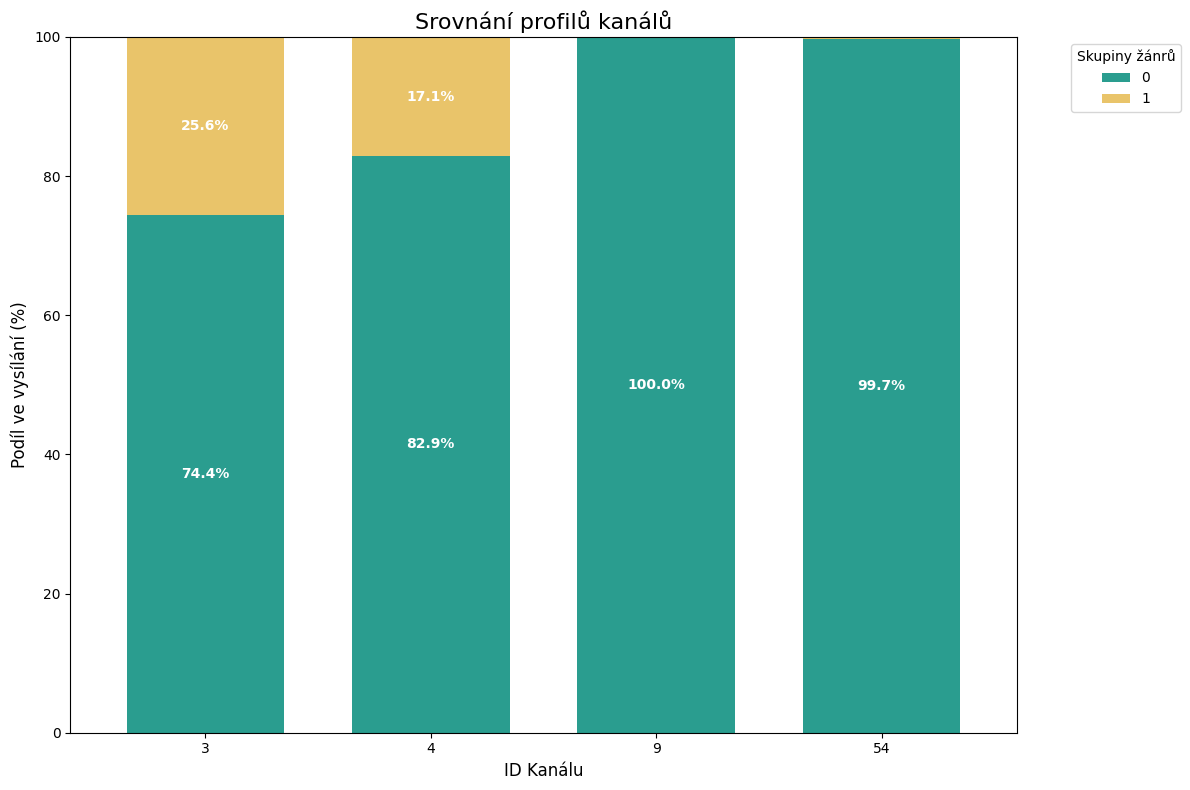

In [30]:
# Vytvoření kontingenční tabulky (procenta)
pivot_df = pd.crosstab(processed_df['channel_id'], processed_df['is_series_content'], normalize='index') * 100

# SEŘAZENÍ: Seřadíme sloupce (žánry) podle jejich celkového průměrného zastoupení
sorted_columns = pivot_df.mean().sort_values(ascending=False).index
pivot_df = pivot_df[sorted_columns]

# 3. Vykreslení
# Použijeme barvy, které od sebe skupiny jasně odliší
colors = [
    '#2a9d8f', # Tyrkysová
    '#e9c46a', # Písková
]
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors, width=0.7)

# 4. Formátování
plt.title('Srovnání profilů kanálů', fontsize=16)
plt.xlabel('ID Kanálu', fontsize=12)
plt.ylabel('Podíl ve vysílání (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Skupiny žánrů', bbox_to_anchor=(1.05, 1), loc='upper left')

# Přidání popisků (jen pokud je plocha dost velká)
for n, x in enumerate([*pivot_df.index.values]):
    cumulative_sum = 0
    for col in pivot_df.columns:
        proportion = pivot_df.loc[x, col]
        if proportion > 4: # Popisek dáme jen tam, kde je víc než 4 %
            plt.text(x=n,
                     y=cumulative_sum + (proportion / 2),
                     s=f'{proportion:.1f}%', 
                     color="white", fontsize=10, fontweight="bold", ha="center", va="center")
        cumulative_sum += proportion

plt.tight_layout()
plt.show()

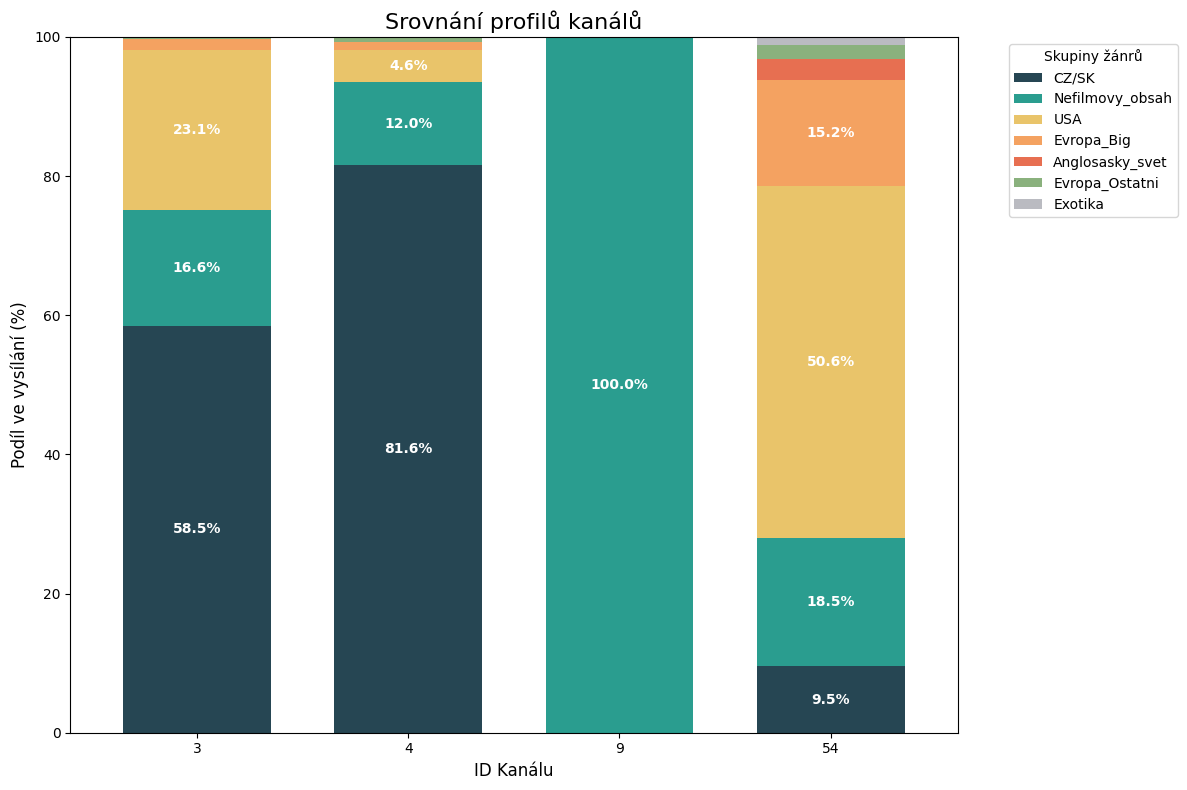

In [28]:
# Vytvoření kontingenční tabulky (procenta)
pivot_df = pd.crosstab(processed_df['channel_id'], processed_df['origin_group'], normalize='index') * 100

# SEŘAZENÍ: Seřadíme sloupce (žánry) podle jejich celkového průměrného zastoupení
sorted_columns = pivot_df.mean().sort_values(ascending=False).index
pivot_df = pivot_df[sorted_columns]

# 3. Vykreslení
# Použijeme barvy, které od sebe skupiny jasně odliší
colors = [
    '#264653', # Tmavý petrolej
    '#2a9d8f', # Tyrkysová
    '#e9c46a', # Písková
    '#f4a261', # Světle oranžová
    '#e76f51', # Terakota
    '#8ab17d', # Šalvějová
    '#babbc1'  # Neutrální šedá (pro "Ostatní")
]
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors, width=0.7)

# 4. Formátování
plt.title('Srovnání profilů kanálů', fontsize=16)
plt.xlabel('ID Kanálu', fontsize=12)
plt.ylabel('Podíl ve vysílání (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Skupiny žánrů', bbox_to_anchor=(1.05, 1), loc='upper left')

# Přidání popisků (jen pokud je plocha dost velká)
for n, x in enumerate([*pivot_df.index.values]):
    cumulative_sum = 0
    for col in pivot_df.columns:
        proportion = pivot_df.loc[x, col]
        if proportion > 4: # Popisek dáme jen tam, kde je víc než 4 %
            plt.text(x=n,
                     y=cumulative_sum + (proportion / 2),
                     s=f'{proportion:.1f}%', 
                     color="white", fontsize=10, fontweight="bold", ha="center", va="center")
        cumulative_sum += proportion

plt.tight_layout()
plt.show()

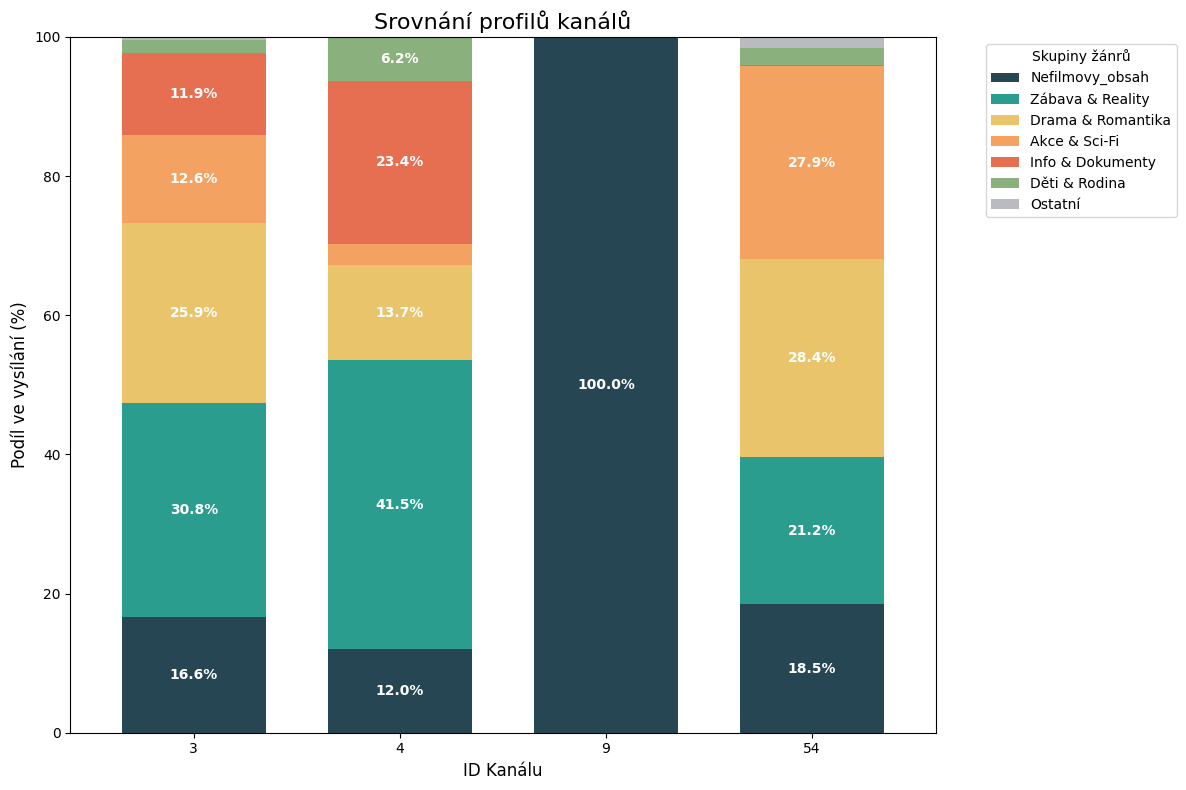

In [ ]:
# Vytvoření kontingenční tabulky (procenta)
pivot_df = pd.crosstab(processed_df['channel_id'], processed_df['genre_group'], normalize='index') * 100

# SEŘAZENÍ: Seřadíme sloupce (žánry) podle jejich celkového průměrného zastoupení
sorted_columns = pivot_df.mean().sort_values(ascending=False).index
pivot_df = pivot_df[sorted_columns]

# 3. Vykreslení
# Použijeme barvy, které od sebe skupiny jasně odliší
colors = [
    '#264653', # Tmavý petrolej
    '#2a9d8f', # Tyrkysová
    '#e9c46a', # Písková
    '#f4a261', # Světle oranžová
    '#e76f51', # Terakota
    '#8ab17d', # Šalvějová
    '#babbc1'  # Neutrální šedá (pro "Ostatní")
]
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors, width=0.7)

# 4. Formátování
plt.title('Srovnání profilů kanálů', fontsize=16)
plt.xlabel('ID Kanálu', fontsize=12)
plt.ylabel('Podíl ve vysílání (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Skupiny žánrů', bbox_to_anchor=(1.05, 1), loc='upper left')

# Přidání popisků (jen pokud je plocha dost velká)
for n, x in enumerate([*pivot_df.index.values]):
    cumulative_sum = 0
    for col in pivot_df.columns:
        proportion = pivot_df.loc[x, col]
        if proportion > 4: # Popisek dáme jen tam, kde je víc než 4 %
            plt.text(x=n,
                     y=cumulative_sum + (proportion / 2),
                     s=f'{proportion:.1f}%', 
                     color="white", fontsize=10, fontweight="bold", ha="center", va="center")
        cumulative_sum += proportion

plt.tight_layout()
plt.show()

sel_df

In [ ]:
# overeni zda se jednoa o 4 kanaly
df.channel_id.unique()

array([ 3,  4,  9, 54])

1. Struktura a formát

    Typ souboru: Jde o klasické CSV (tabulková data).

    Klíčové sloupce (Features):

        channel id: Identifikátor televizní stanice (víme, že jsou tam 4 vybrané kanály).

        timeslot datetime from: Časový údaj (datum a čas začátku pořadu/slotu).

        main indent: Unikátní ID pořadu nebo filmu (klíč k tomu, co se zrovna vysílalo).

    Cílové proměnné (Targets):

        share 15 54: Aktuální tržní podíl (sledovanost) v klíčové komerční skupině 15–54 let.

        share 15 54 3mo mean: Klouzavý průměr tohoto podílu za poslední 3 měsíce.


2. Povaha dat (Business kontext)

    Časová řada (Time-Series): Data jsou řazena v čase. Budeš muset řešit sezónnost (den vs. noc, pracovní den vs. víkend).

    Televizní trh: Hodnota share (podíl) je relativní číslo (obvykle v procentech). Součet podílů všech stanic na trhu v daný čas je 100 %.

    Granularita: Pravděpodobně jde o data po "slotech" (pořadech), nikoliv po minutách, protože se odkazují na main indent (ID filmu).